Dataset creado con dimensiones: (5000, 16)

--- 2. EDA Básico ---


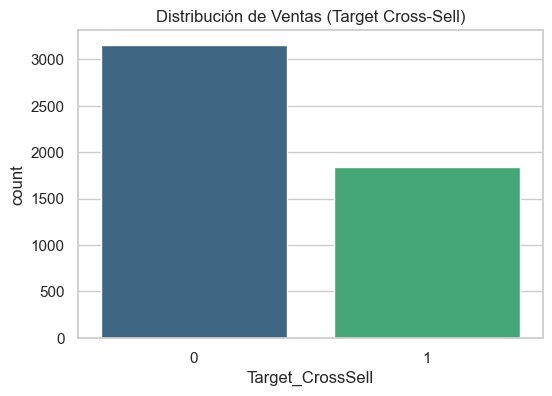


--- 4. Segmentación con Gaussian Mixture Models ---


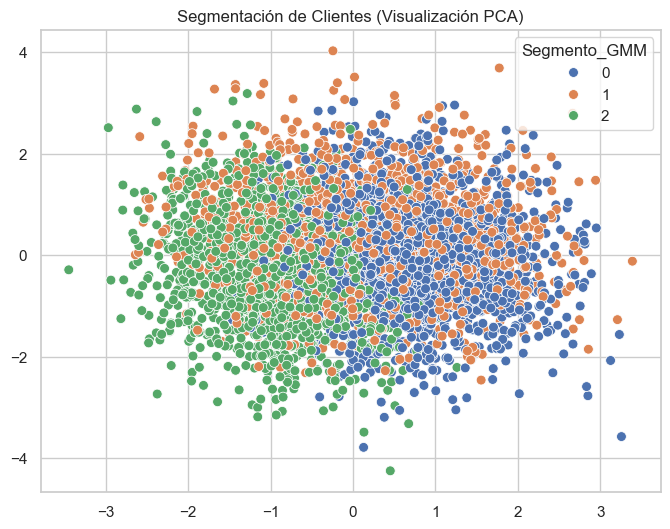


--- 5. Modelo de Predicción de Cross-Selling ---

Variables más influyentes:
                Feature      Coef
0                  Edad  0.349442
6      Score_Crediticio  0.217730
5         Ingreso_Anual  0.128244
8  Tenencia_Banca_Anios  0.066732
4             Ubicacion  0.021861

--- 6. Evaluación del Modelo ---
Confusion Matrix:
 [[788 143]
 [370 199]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.75       931
           1       0.58      0.35      0.44       569

    accuracy                           0.66      1500
   macro avg       0.63      0.60      0.60      1500
weighted avg       0.64      0.66      0.63      1500

AUC Score: 0.7029

--- 7. Perfilamiento de Riesgo y Probabilidades ---
      ID_Cliente  Score_Crediticio Nivel_Riesgo_Cliente  Probabilidad_Compra  \
1501        2501               793                 Bajo             0.412048   
2586        3586               584                 Alto    

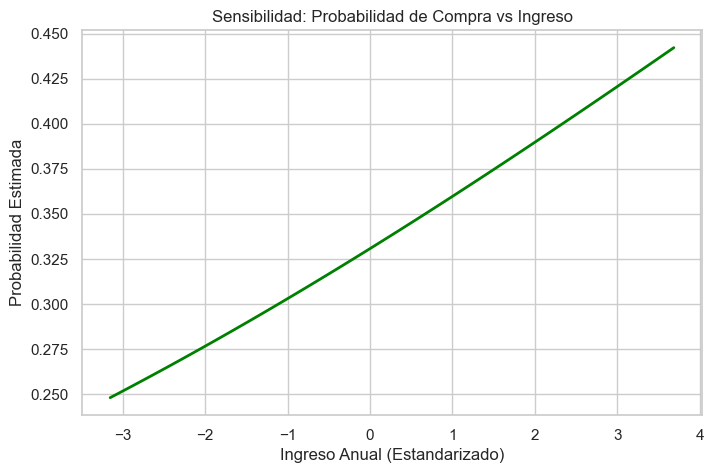


Proceso Finalizado Exitosamente.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Configuración de estilo
sns.set(style="whitegrid")
np.random.seed(42)  # Para reproducibilidad

# =============================================================================
# 1. GENERACIÓN DE DATOS SINTÉTICOS (SIMULACIÓN PROFESIONAL)
# =============================================================================
# Simulamos 5,000 clientes con 15 variables clave
n_samples = 5000

data = {
    # --- Variables Demográficas ---
    'ID_Cliente': np.arange(1000, 1000 + n_samples),
    'Edad': np.random.randint(18, 75, n_samples),
    'Genero': np.random.choice(['M', 'F'], n_samples),
    'Estado_Civil': np.random.choice(['Soltero', 'Casado', 'Divorciado'], n_samples),
    'Nivel_Educacion': np.random.choice(['Secundaria', 'Universitario', 'Postgrado'], n_samples),
    'Ubicacion': np.random.choice(['Urbano', 'Rural', 'Suburbano'], n_samples),
    
    # --- Variables Financieras ---
    'Ingreso_Anual': np.random.normal(50000, 15000, n_samples).astype(int),
    'Score_Crediticio': np.random.normal(650, 100, n_samples).astype(int), # 300-850
    'Saldo_Cuenta': np.random.normal(12000, 5000, n_samples),
    'Tenencia_Banca_Anios': np.random.randint(1, 20, n_samples),
    
    # --- Variables de Comportamiento ---
    'Num_Productos_Activos': np.random.randint(1, 5, n_samples),
    'Tiene_Tarjeta_Credito': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'Es_Miembro_Activo': np.random.choice([0, 1], n_samples),
    'Transacciones_Mensuales_Prom': np.random.randint(0, 50, n_samples),
    
    # --- Variables de Riesgo/Seguros ---
    'Reclamos_Anteriores': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]), # 1 si ha reclamado antes
}

df = pd.DataFrame(data)

# Ajustes lógicos de negocio
df['Saldo_Cuenta'] = df['Saldo_Cuenta'] + (df['Score_Crediticio'] * 5)
df['Ingreso_Anual'] = np.where(df['Edad'] > 40, df['Ingreso_Anual'] * 1.2, df['Ingreso_Anual'])

# --- Variable Objetivo (Target): ¿Compra el Seguro? (Cross_Sell) ---
logit = (df['Edad'] * 0.02) + (df['Ingreso_Anual'] * 0.00001) + (df['Score_Crediticio'] * 0.002) - (df['Reclamos_Anteriores'] * 2) - 3
prob_compra = 1 / (1 + np.exp(-logit))
df['Target_CrossSell'] = np.random.binomial(1, prob_compra)

print(f"Dataset creado con dimensiones: {df.shape}")

# =============================================================================
# 2. EDA (ANÁLISIS EXPLORATORIO DE DATOS)
# =============================================================================
print("\n--- 2. EDA Básico ---")

# Distribución del Target
plt.figure(figsize=(6, 4))
sns.countplot(x='Target_CrossSell', data=df, palette='viridis')
plt.title('Distribución de Ventas (Target Cross-Sell)')
plt.show()

# =============================================================================
# 3. PREPROCESAMIENTO
# =============================================================================
# Codificación de variables categóricas
categorical_cols = ['Genero', 'Estado_Civil', 'Nivel_Educacion', 'Ubicacion']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Selección de características (X) y Target (y)
features = [col for col in df.columns if col not in ['ID_Cliente', 'Target_CrossSell']]
X = df[features]
y = df['Target_CrossSell']

# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# =============================================================================
# 4. SEGMENTACIÓN DE CLIENTES (CLUSTERING con GMM)
# =============================================================================
print("\n--- 4. Segmentación con Gaussian Mixture Models ---")
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# Asignar clusters
df['Segmento_GMM'] = gmm.predict(X_scaled)

# Visualización PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Segmento_GMM'], palette='deep', s=50)
plt.title('Segmentación de Clientes (Visualización PCA)')
plt.show()

# =============================================================================
# 5. MODELADO PREDICTIVO (REGRESIÓN LOGÍSTICA)
# =============================================================================
print("\n--- 5. Modelo de Predicción de Cross-Selling ---")

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Modelo
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Predicciones
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Importancia de variables
coefs = pd.DataFrame({'Feature': features, 'Coef': log_reg.coef_[0]})
print("\nVariables más influyentes:")
print(coefs.sort_values(by='Coef', ascending=False).head(5))

# =============================================================================
# 6. EVALUACIÓN DE MÉTRICAS
# =============================================================================
print("\n--- 6. Evaluación del Modelo ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Curva ROC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
print(f"AUC Score: {roc_auc:.4f}")

# =============================================================================
# 7. ANÁLISIS DE RIESGO Y RECOMENDACIÓN (CORREGIDO)
# =============================================================================
print("\n--- 7. Perfilamiento de Riesgo y Probabilidades ---")

indices_test = y_test.index
df_results = df.loc[indices_test].copy()

df_results['Probabilidad_Compra'] = y_prob
df_results['Prediccion_Compra'] = y_pred

# --- CLASIFICACIÓN DE RIESGO ---
conditions = [
    (df_results['Score_Crediticio'] < 600),
    (df_results['Score_Crediticio'] >= 600) & (df_results['Score_Crediticio'] < 750),
    (df_results['Score_Crediticio'] >= 750)
]
choices = ['Alto', 'Medio', 'Bajo']

# CORRECCIÓN APLICADA: Se agrega default='Desconocido' para evitar el TypeError
df_results['Nivel_Riesgo_Cliente'] = np.select(conditions, choices, default='Desconocido')

cols_view = ['ID_Cliente', 'Score_Crediticio', 'Nivel_Riesgo_Cliente', 'Probabilidad_Compra', 'Prediccion_Compra']
print(df_results[cols_view].head(10))

# =============================================================================
# 8. ANÁLISIS DE SENSIBILIDAD
# =============================================================================
print("\n--- 8. Análisis de Sensibilidad (Ingreso Anual) ---")

cliente_promedio = X_scaled_df.mean().values.reshape(1, -1)
idx_ingreso = features.index('Ingreso_Anual')

rango_ingresos = np.linspace(X_scaled_df['Ingreso_Anual'].min(), X_scaled_df['Ingreso_Anual'].max(), 50)
probabilidades_sensibilidad = []

for val in rango_ingresos:
    cliente_temp = cliente_promedio.copy()
    cliente_temp[0, idx_ingreso] = val 
    prob = log_reg.predict_proba(cliente_temp)[:, 1][0]
    probabilidades_sensibilidad.append(prob)

plt.figure(figsize=(8, 5))
plt.plot(rango_ingresos, probabilidades_sensibilidad, color='green', linewidth=2)
plt.title('Sensibilidad: Probabilidad de Compra vs Ingreso')
plt.xlabel('Ingreso Anual (Estandarizado)')
plt.ylabel('Probabilidad Estimada')
plt.show()

print("\nProceso Finalizado Exitosamente.")